In [1]:
!pip install statsmodels --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Plot styling
PALETTE = ['#008751', '#00B366', '#FF6B35', '#FFC107', '#E63946', '#457B9D']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

np.random.seed(42)

---
## Synthetic Dataset Generation

I generate weekly data for 6 Nigerian markets × 8 food commodities from 2022–2024.  
Demand patterns reflect real Nigerian conditions:
-  Rainy season boost (Apr–Oct) |  Harmattan dampening (Nov–Feb)
-  Christmas/New Year spike (+60%) |  Ramadan & Sallah spikes (+25–35%)
-  End-of-month salary effect |  Random supply disruptions (flooding, road closures)

In [3]:
# Commodity & Market Configuration

COMMODITIES = {
    'Rice (50kg bag)':     {'base_demand': 300, 'unit_cost': 42000,  'lead_time_days': 7},
    'Maize (50kg bag)':    {'base_demand': 250, 'unit_cost': 18000,  'lead_time_days': 5},
    'Yam (tuber)':         {'base_demand': 400, 'unit_cost': 2500,   'lead_time_days': 3},
    'Tomatoes (basket)':   {'base_demand': 500, 'unit_cost': 8000,   'lead_time_days': 2},
    'Palm Oil (25L)':      {'base_demand': 180, 'unit_cost': 35000,  'lead_time_days': 6},
    'Garri (50kg bag)':    {'base_demand': 350, 'unit_cost': 22000,  'lead_time_days': 4},
    'Beans (50kg bag)':    {'base_demand': 220, 'unit_cost': 55000,  'lead_time_days': 6},
    'Groundnut Oil (20L)': {'base_demand': 150, 'unit_cost': 28000,  'lead_time_days': 5},
}

MARKETS = ['Lagos', 'Kano', 'Abuja', 'Port Harcourt', 'Onitsha', 'Ibadan']

MARKET_MULTIPLIERS = {
    'Lagos': 1.8, 'Kano': 1.4, 'Abuja': 1.5,
    'Port Harcourt': 1.3, 'Onitsha': 1.6, 'Ibadan': 1.2,
}

In [4]:
# Demand Pattern Functions

def get_seasonal_factor(date):
    """Nigerian seasonal demand patterns."""
    month = date.month
    harmattan = 0.85 if month in [11, 12, 1, 2] else 1.0
    rainy     = 1.10 if month in [4, 5, 6, 7, 8, 9, 10] else 1.0
    return harmattan * rainy

def get_festive_factor(date):
    """Demand spikes during Nigerian festive periods."""
    month, day = date.month, date.day
    if (month == 12 and day >= 20) or (month == 1 and day <= 5):  # Christmas/New Year
        return 1.6
    if month == 4 and 10 <= day <= 20:                             # Easter
        return 1.3
    if (month == 3 and day >= 20) or (month == 4 and day <= 20):  # Ramadan
        return 1.25
    if month == 6 and 15 <= day <= 25:                            # Sallah (Eid)
        return 1.35
    if day >= 27:                                                  # End-of-month
        return 1.1
    return 1.0

def get_supply_shock(date):
    """Random supply disruptions: flooding, road closures, strikes."""
    np.random.seed(date.toordinal())
    shock = np.random.random()
    if shock < 0.04:   return 0.50   # 4%: major disruption
    elif shock < 0.10: return 0.75   # 6%: minor disruption
    return 1.0

In [5]:
# Dataset Generator

def generate_dataset(start_date='2022-01-01', end_date='2024-12-31'):
    dates = pd.date_range(start=start_date, end=end_date, freq='W')
    records = []

    for market in MARKETS:
        market_mult = MARKET_MULTIPLIERS[market]
        for commodity, info in COMMODITIES.items():
            stock_level = info['base_demand'] * market_mult * 4  # ~4 weeks opening stock

            for date in dates:
                seasonal     = get_seasonal_factor(date)
                festive      = get_festive_factor(date)
                supply_shock = get_supply_shock(date)
                noise        = np.random.normal(1.0, 0.12)

                demand = int(info['base_demand'] * market_mult * seasonal * festive * noise)
                demand = max(10, demand)

                stock_received = 0
                if stock_level < (demand * 2):
                    stock_received = int(demand * 3 * supply_shock)

                stock_level = max(0, stock_level + stock_received - demand)

                records.append({
                    'date':           date,
                    'market':         market,
                    'commodity':      commodity,
                    'demand_units':   demand,
                    'stock_level':    int(stock_level),
                    'stock_received': stock_received,
                    'unit_cost_ngn':  info['unit_cost'],
                    'lead_time_days': info['lead_time_days'],
                    'seasonal_factor': round(seasonal, 2),
                    'festive_factor':  round(festive, 2),
                    'supply_shock':    round(supply_shock, 2),
                })

    return pd.DataFrame(records)


# Generate and preview
df = generate_dataset()
print(f' Dataset generated: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Date range : {df.date.min().date()} → {df.date.max().date()}')
print(f'   Markets    : {df.market.nunique()} | Commodities: {df.commodity.nunique()}')
df.head()

 Dataset generated: 7,536 rows × 11 columns
   Date range : 2022-01-02 → 2024-12-29
   Markets    : 6 | Commodities: 8


,date,market,commodity,demand_units,stock_level,stock_received,unit_cost_ngn,lead_time_days,seasonal_factor,festive_factor,supply_shock
0,2022-01-02,Lagos,Rice (50kg bag),645,1515,0,42000,7,0.85,1.6,1.0
1,2022-01-09,Lagos,Rice (50kg bag),457,1058,0,42000,7,0.85,1.0,1.0
2,2022-01-16,Lagos,Rice (50kg bag),490,568,0,42000,7,0.85,1.0,1.0
3,2022-01-23,Lagos,Rice (50kg bag),399,1366,1197,42000,7,0.85,1.0,1.0
4,2022-01-30,Lagos,Rice (50kg bag),560,806,0,42000,7,0.85,1.1,1.0


In [6]:
# Demand summary statistics by commodity
summary = df.groupby('commodity')['demand_units'].agg(['mean','std','min','max']).round(1)
summary.columns = ['Avg Weekly Demand', 'Std Dev', 'Min', 'Max']
summary.sort_values('Avg Weekly Demand', ascending=False)

,Avg Weekly Demand,Std Dev,Min,Max
commodity,,,,
Tomatoes (basket),785.8,187.2,402,1577
Yam (tuber),628.5,149.7,321,1261
Garri (50kg bag),549.9,131.0,281,1104
Rice (50kg bag),471.3,112.3,241,946
Maize (50kg bag),392.6,93.6,201,788
Beans (50kg bag),345.4,82.3,177,694
Palm Oil (25L),282.5,67.4,144,567
Groundnut Oil (20L),235.4,56.2,120,473


In [7]:
# Save dataset (
df.to_csv('nigeria_food_supply.csv', index=False)

---
## Exploratory Visualizations

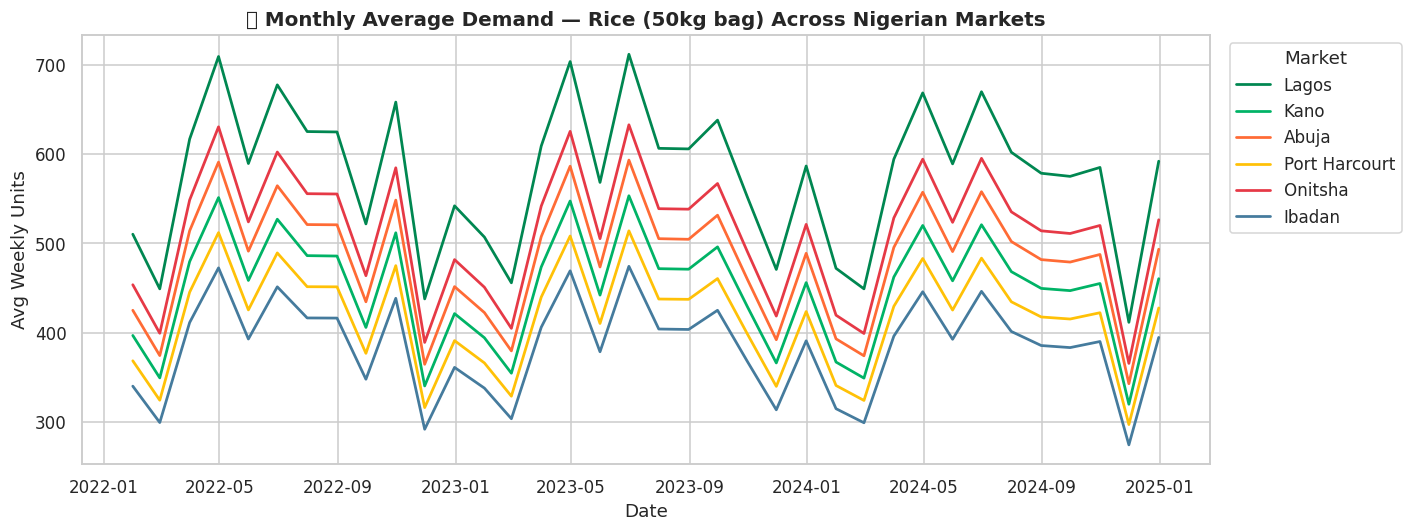

In [8]:
# Market comparison — monthly average demand across markets for Rice
def plot_market_comparison(df, commodity):
    fig, ax = plt.subplots(figsize=(13, 5))
    mask = df['commodity'] == commodity
    for i, market in enumerate(df['market'].unique()):
        mdata = df[mask & (df['market'] == market)].set_index('date')['demand_units']
        mdata = mdata.resample('ME').mean()
        ax.plot(mdata.index, mdata.values, label=market,
                color=PALETTE[i % len(PALETTE)], linewidth=1.8)
    ax.set_title(f' Monthly Average Demand — {commodity} Across Nigerian Markets',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg Weekly Units')
    ax.legend(title='Market', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

plot_market_comparison(df, 'Rice (50kg bag)')

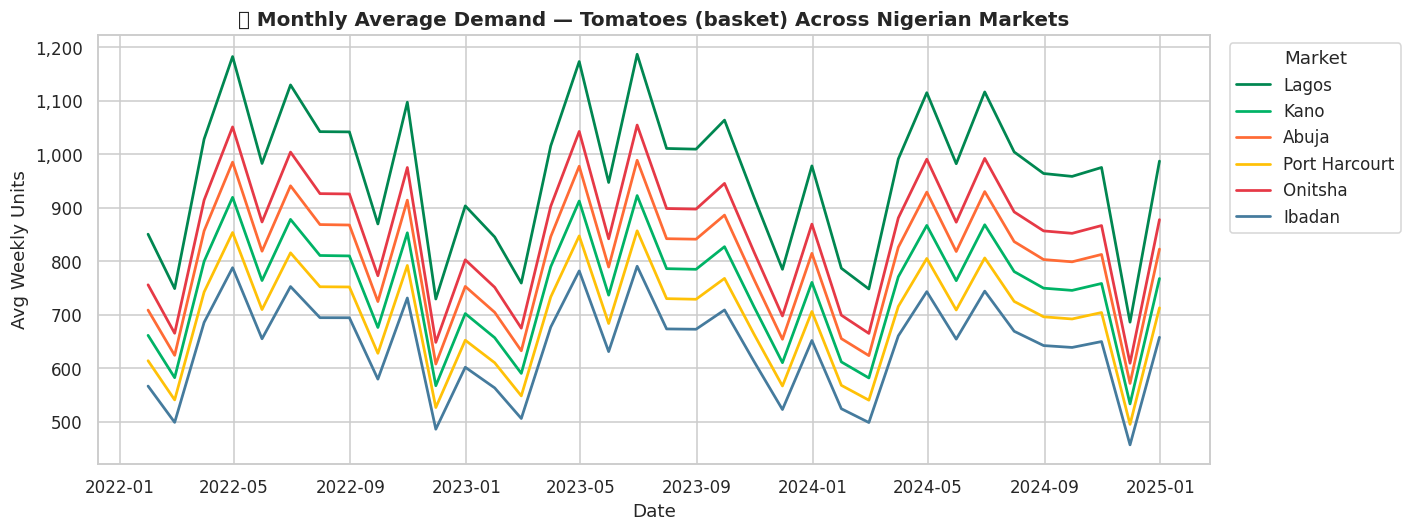

In [9]:
plot_market_comparison(df, 'Tomatoes (basket)')

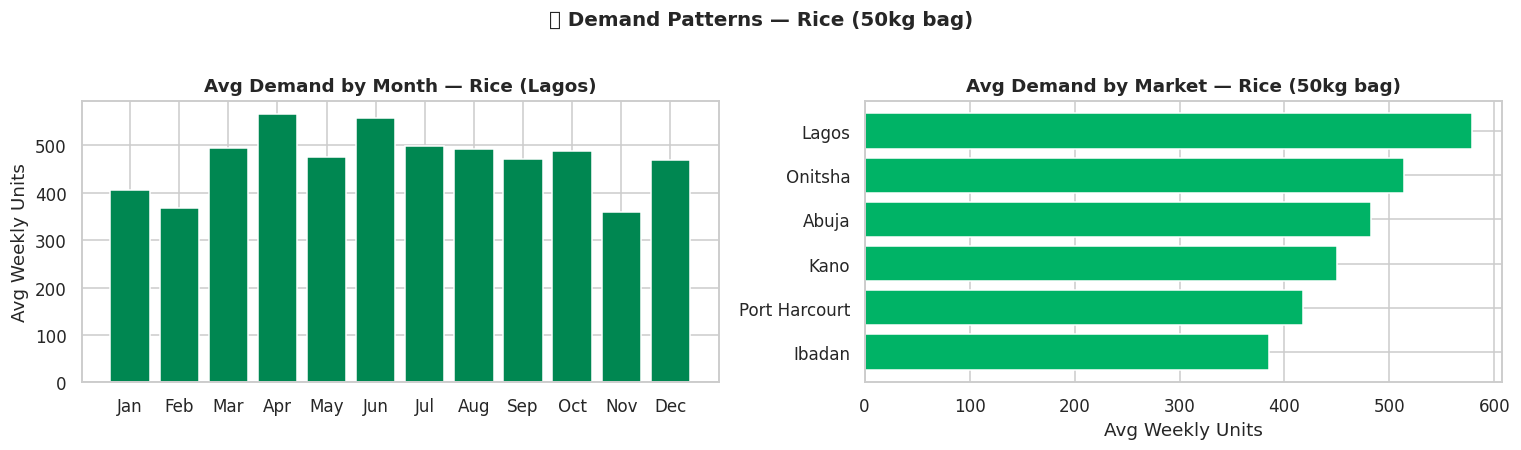

In [10]:
# Festive demand pattern shows how demand spikes around key periods
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By month
monthly = df[df['commodity'] == 'Rice (50kg bag)'].groupby(df['date'].dt.month)['demand_units'].mean()
axes[0].bar(monthly.index, monthly.values, color=PALETTE[0], edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_title('Avg Demand by Month — Rice (Lagos)', fontweight='bold')
axes[0].set_ylabel('Avg Weekly Units')

# By market
by_market = df[df['commodity'] == 'Rice (50kg bag)'].groupby('market')['demand_units'].mean().sort_values(ascending=True)
axes[1].barh(by_market.index, by_market.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Avg Demand by Market — Rice (50kg bag)', fontweight='bold')
axes[1].set_xlabel('Avg Weekly Units')

plt.suptitle(' Demand Patterns — Rice (50kg bag)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Demand Forecasting

**Holt-Winters Exponential Smoothing** captures:
- **Level** — overall average demand
- **Trend** — upward/downward drift
- **Seasonality** — annual cycles (52-week period)

In [11]:
# Forecasting Functions

def prepare_series(df, market, commodity):
    mask = (df['market'] == market) & (df['commodity'] == commodity)
    series = df[mask].set_index('date')['demand_units'].sort_index()
    return series.asfreq('W')

def forecast_holt_winters(series, periods=12):
    model = ExponentialSmoothing(
        series,
        trend='add',
        seasonal='add',
        seasonal_periods=52,
        initialization_method='estimated',
    )
    fit = model.fit(optimized=True)
    forecast = fit.forecast(periods)
    ci = pd.DataFrame({'lower': forecast * 0.85, 'upper': forecast * 1.15}, index=forecast.index)
    mae  = np.mean(np.abs(fit.fittedvalues - series))
    mape = np.mean(np.abs((fit.fittedvalues - series) / series)) * 100
    return forecast, ci, fit, round(mae, 1), round(mape, 1)

def run_all_forecasts(df, periods=12):
    results = {}
    for market in df['market'].unique():
        for commodity in df['commodity'].unique():
            series = prepare_series(df, market, commodity)
            if len(series) < 20:
                continue
            try:
                forecast, ci, fit, mae, mape = forecast_holt_winters(series, periods)
                results[(market, commodity)] = {
                    'forecast': forecast, 'ci': ci,
                    'history': series, 'mae': mae, 'mape': mape,
                }
            except Exception as e:
                print(f'   Skipped {market} | {commodity}: {e}')
    return results

print('Forecasting functions defined. Running forecasts...')
forecast_results = run_all_forecasts(df, periods=12)
print(f'Forecasts complete for {len(forecast_results)} market-commodity pairs.')

Forecasting functions defined. Running forecasts...
Forecasts complete for 48 market-commodity pairs.


In [12]:
# Forecast Summary Table

fc_rows = []
for (market, commodity), data in forecast_results.items():
    fc = data['forecast']
    fc_rows.append({
        'Market':    market,
        'Commodity': commodity,
        'Avg Forecast (weekly)': round(fc.mean(), 1),
        'Peak Forecast (weekly)': round(fc.max(), 1),
        'Min Forecast (weekly)':  round(fc.min(), 1),
        'MAE':   data['mae'],
        'MAPE %': data['mape'],
    })

fc_summary = pd.DataFrame(fc_rows).sort_values(['Market', 'Commodity'])
print(f'Average MAPE across all pairs: {fc_summary["MAPE %"].mean():.1f}%')
fc_summary

Average MAPE across all pairs: 6.9%


,Market,Commodity,Avg Forecast (weekly),Peak Forecast (weekly),Min Forecast (weekly),MAE,MAPE %
22,Abuja,Beans (50kg bag),301.8,424.8,254.8,23.8,6.9
21,Abuja,Garri (50kg bag),480.3,676.6,405.3,38.0,6.9
23,Abuja,Groundnut Oil (20L),205.4,289.4,173.4,16.3,6.9
17,Abuja,Maize (50kg bag),342.8,482.8,289.2,27.1,6.9
20,Abuja,Palm Oil (25L),246.5,347.6,207.9,19.5,6.9
16,Abuja,Rice (50kg bag),411.5,579.7,347.4,32.5,6.9
19,Abuja,Tomatoes (basket),685.8,966.1,578.9,54.2,6.9
18,Abuja,Yam (tuber),548.9,773.1,463.0,43.4,6.9
46,Ibadan,Beans (50kg bag),241.0,339.6,203.6,19.1,6.9
45,Ibadan,Garri (50kg bag),383.8,540.7,324.0,30.4,6.9


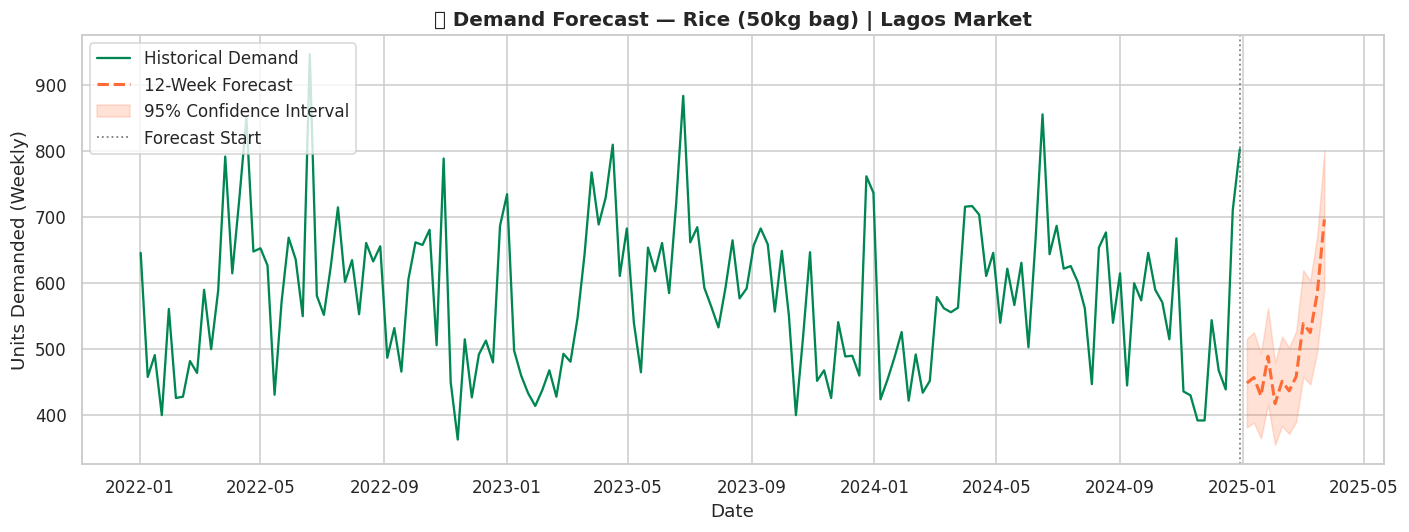

   MAPE: 6.9% | MAE: 39.1 units


In [13]:
# Demand Trend + Forecast Plot

def plot_demand_trend(results, market, commodity):
    key = (market, commodity)
    if key not in results:
        print(f'No data for {market} | {commodity}')
        return
    data = results[key]
    history, forecast, ci = data['history'], data['forecast'], data['ci']

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(history.index, history.values, color='#008751', linewidth=1.5, label='Historical Demand')
    ax.plot(forecast.index, forecast.values, color='#FF6B35', linewidth=2,
            linestyle='--', label='12-Week Forecast')
    ax.fill_between(forecast.index, ci['lower'], ci['upper'],
                    alpha=0.2, color='#FF6B35', label='95% Confidence Interval')
    ax.axvline(history.index[-1], color='gray', linestyle=':', linewidth=1.2, label='Forecast Start')
    ax.set_title(f'📈 Demand Forecast — {commodity} | {market} Market',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Units Demanded (Weekly)')
    ax.legend(loc='upper left')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()
    print(f'   MAPE: {data["mape"]}% | MAE: {data["mae"]} units')

plot_demand_trend(forecast_results, 'Lagos', 'Rice (50kg bag)')

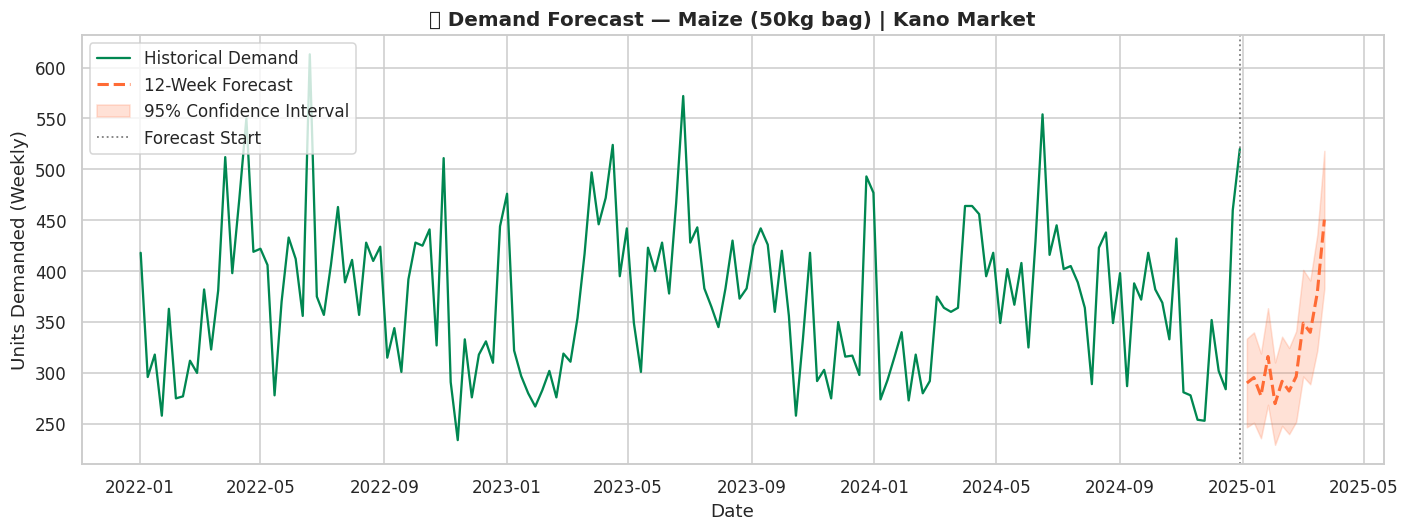

   MAPE: 6.9% | MAE: 25.3 units


In [14]:
plot_demand_trend(forecast_results, 'Kano', 'Maize (50kg bag)')

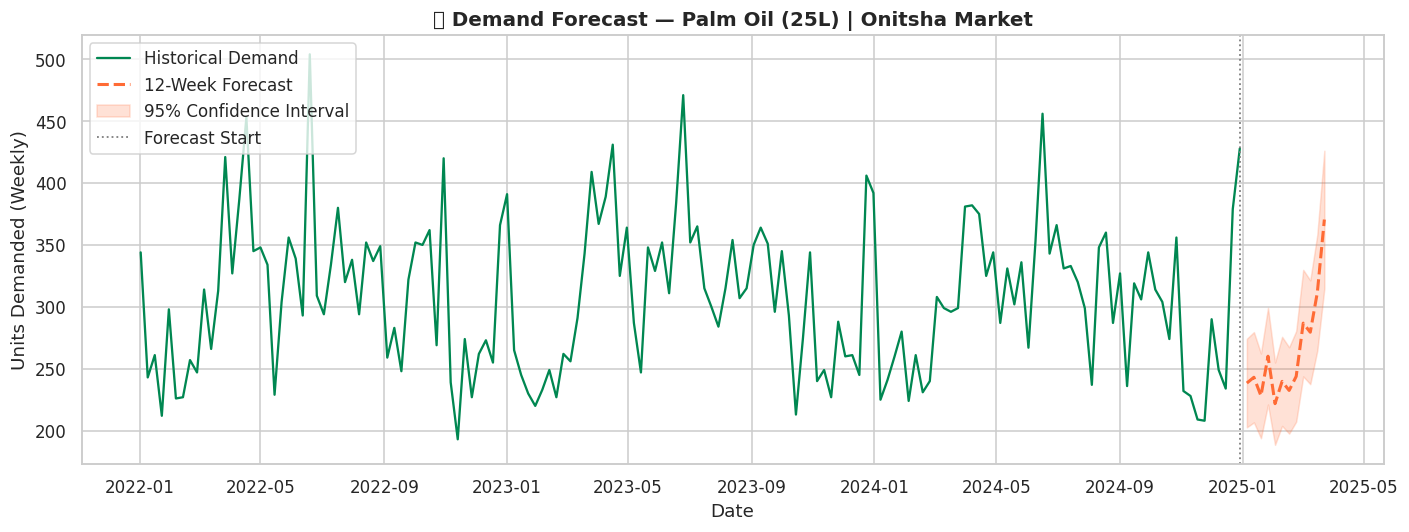

   MAPE: 6.9% | MAE: 20.9 units


In [15]:
plot_demand_trend(forecast_results, 'Onitsha', 'Palm Oil (25L)')

---
## Inventory Optimization (EOQ + Safety Stock)

| Formula | Description |
|---|---|
| **EOQ** = √(2DS/H) | Minimizes total annual ordering + holding costs |
| **Safety Stock** = Z × σ × √(lead time) | Buffers against demand variability (95% service level) |
| **Reorder Point** = avg demand × lead time + safety stock | Trigger point for placing a new order |

In [16]:
# Inventory Optimization Constants
HOLDING_COST_RATE = 0.20    # 20% of unit cost/year (storage, spoilage, capital)
ORDERING_COST_NGN = 15_000  # Fixed cost per order (₦) — transport, admin
SERVICE_LEVEL_Z   = 1.645   # 95% service level


# Core Inventory Formulas

def economic_order_quantity(annual_demand, unit_cost):
    H = unit_cost * HOLDING_COST_RATE
    if H <= 0 or annual_demand <= 0: return 0
    return int(np.sqrt((2 * annual_demand * ORDERING_COST_NGN) / H))

def safety_stock(demand_std_weekly, lead_time_days):
    lead_time_weeks = lead_time_days / 7
    return int(SERVICE_LEVEL_Z * demand_std_weekly * np.sqrt(lead_time_weeks))

def reorder_point(avg_weekly_demand, lead_time_days, ss):
    return int(avg_weekly_demand * (lead_time_days / 7) + ss)

def weeks_of_stock(current_stock, avg_weekly_demand):
    return round(current_stock / avg_weekly_demand, 1) if avg_weekly_demand > 0 else 999

def risk_status(current_stock, rop):
    if current_stock <= 0: return 'STOCKOUT'
    ratio = current_stock / rop if rop > 0 else 999
    if ratio < 0.5:  return 'CRITICAL'
    if ratio < 1.0:  return 'LOW - REORDER NOW'
    if ratio < 1.5:  return 'MODERATE'
    return 'ADEQUATE'


#  Run Optimization

def optimize_inventory(df):
    rows = []
    for (market, commodity), grp in df.groupby(['market', 'commodity']):
        grp          = grp.sort_values('date')
        unit_cost    = grp['unit_cost_ngn'].iloc[0]
        lead_time    = grp['lead_time_days'].iloc[0]
        avg_demand   = grp['demand_units'].mean()
        std_demand   = grp['demand_units'].std()
        annual_demand = avg_demand * 52
        current_stock = grp['stock_level'].iloc[-1]

        eoq  = economic_order_quantity(annual_demand, unit_cost)
        ss   = safety_stock(std_demand, lead_time)
        rop  = reorder_point(avg_demand, lead_time, ss)
        wos  = weeks_of_stock(current_stock, avg_demand)
        risk = risk_status(current_stock, rop)

        order_freq          = annual_demand / eoq if eoq > 0 else 0
        annual_ordering     = order_freq * ORDERING_COST_NGN
        avg_inventory       = eoq / 2 + ss
        annual_holding      = avg_inventory * unit_cost * HOLDING_COST_RATE
        total_annual_cost   = annual_ordering + annual_holding

        rows.append({
            'market':               market,
            'commodity':            commodity,
            'avg_weekly_demand':    round(avg_demand, 1),
            'demand_std_weekly':    round(std_demand, 1),
            'current_stock':        int(current_stock),
            'weeks_of_stock':       wos,
            'safety_stock':         ss,
            'reorder_point':        rop,
            'eoq_units':            eoq,
            'risk_status':          risk,
            'unit_cost_ngn':        unit_cost,
            'annual_holding_cost':  round(annual_holding),
            'annual_ordering_cost': round(annual_ordering),
            'total_annual_cost':    round(total_annual_cost),
            'lead_time_days':       lead_time,
        })
    return pd.DataFrame(rows).sort_values(['risk_status', 'market'])


opt_df = optimize_inventory(df)
print(f'Optimization complete for {len(opt_df)} market-commodity pairs.')
print('\nRisk Distribution:')
print(opt_df['risk_status'].value_counts().to_string())

Optimization complete for 48 market-commodity pairs.

Risk Distribution:
risk_status
ADEQUATE    48


In [17]:
# Full optimization table
opt_df[['market','commodity','current_stock','weeks_of_stock',
        'reorder_point','safety_stock','eoq_units','risk_status',
        'total_annual_cost']].head(20)

,market,commodity,current_stock,weeks_of_stock,reorder_point,safety_stock,eoq_units,risk_status,total_annual_cost
0,Abuja,Beans (50kg bag),1106,3.1,407,105,223,ADEQUATE,3617412
1,Abuja,Garri (50kg bag),1634,2.9,457,136,446,ADEQUATE,2563183
2,Abuja,Groundnut Oil (20L),740,3.1,236,65,258,ADEQUATE,1814311
3,Abuja,Maize (50kg bag),1232,3.1,395,109,417,ADEQUATE,1894108
4,Abuja,Palm Oil (25L),890,3.1,333,86,253,ADEQUATE,2378370
5,Abuja,Rice (50kg bag),1396,2.9,635,154,299,ADEQUATE,3806741
6,Abuja,Tomatoes (basket),2556,3.2,366,137,885,ADEQUATE,1635501
7,Abuja,Yam (tuber),1862,2.9,410,135,1416,ADEQUATE,775590
8,Ibadan,Beans (50kg bag),883,3.1,326,84,200,ADEQUATE,3125762
9,Ibadan,Garri (50kg bag),1262,2.8,366,109,399,ADEQUATE,2236726


---
## Reorder Alerts & Recommendations

In [18]:
# Generate reorder alerts
ALERT_STATUSES = ['STOCKOUT', 'CRITICAL', 'LOW - REORDER NOW']
alerts = opt_df[opt_df['risk_status'].isin(ALERT_STATUSES)].copy()
alerts['recommended_order_qty'] = alerts['eoq_units']
alerts['estimated_cost_ngn']    = alerts['recommended_order_qty'] * alerts['unit_cost_ngn']

print(f' {len(alerts)} active reorder alerts')
alerts[['market','commodity','risk_status','current_stock',
        'reorder_point','weeks_of_stock','recommended_order_qty','estimated_cost_ngn']]

 0 active reorder alerts


,market,commodity,risk_status,current_stock,reorder_point,weeks_of_stock,recommended_order_qty,estimated_cost_ngn


In [19]:
# recommendations

print('  INVENTORY RECOMMENDATIONS')
for _, row in opt_df.iterrows():
    s = row['risk_status']
    c, m = row['commodity'], row['market']
    if s == 'STOCKOUT':
        print(f" URGENT  | {m:15} | {c:25} | OUT OF STOCK — order {row['eoq_units']} units immediately")
    elif s == 'CRITICAL':
        print(f" CRITICAL| {m:15} | {c:25} | {row['weeks_of_stock']} wks left — order {row['eoq_units']} units now")
    elif s == 'LOW - REORDER NOW':
        print(f" REORDER | {m:15} | {c:25} | Below ROP ({row['current_stock']} < {row['reorder_point']}) — order {row['eoq_units']} units")
    elif s == 'MODERATE':
        print(f" MONITOR | {m:15} | {c:25} | {row['weeks_of_stock']} wks stock — watch closely")
    else:
        print(f" OK      | {m:15} | {c:25} | {row['weeks_of_stock']} wks of stock")

  INVENTORY RECOMMENDATIONS
 OK      | Abuja           | Beans (50kg bag)          | 3.1 wks of stock
 OK      | Abuja           | Garri (50kg bag)          | 2.9 wks of stock
 OK      | Abuja           | Groundnut Oil (20L)       | 3.1 wks of stock
 OK      | Abuja           | Maize (50kg bag)          | 3.1 wks of stock
 OK      | Abuja           | Palm Oil (25L)            | 3.1 wks of stock
 OK      | Abuja           | Rice (50kg bag)           | 2.9 wks of stock
 OK      | Abuja           | Tomatoes (basket)         | 3.2 wks of stock
 OK      | Abuja           | Yam (tuber)               | 2.9 wks of stock
 OK      | Ibadan          | Beans (50kg bag)          | 3.1 wks of stock
 OK      | Ibadan          | Garri (50kg bag)          | 2.8 wks of stock
 OK      | Ibadan          | Groundnut Oil (20L)       | 2.8 wks of stock
 OK      | Ibadan          | Maize (50kg bag)          | 3.1 wks of stock
 OK      | Ibadan          | Palm Oil (25L)            | 3.1 wks of stock
 OK      |

---
## Visual Dashboards

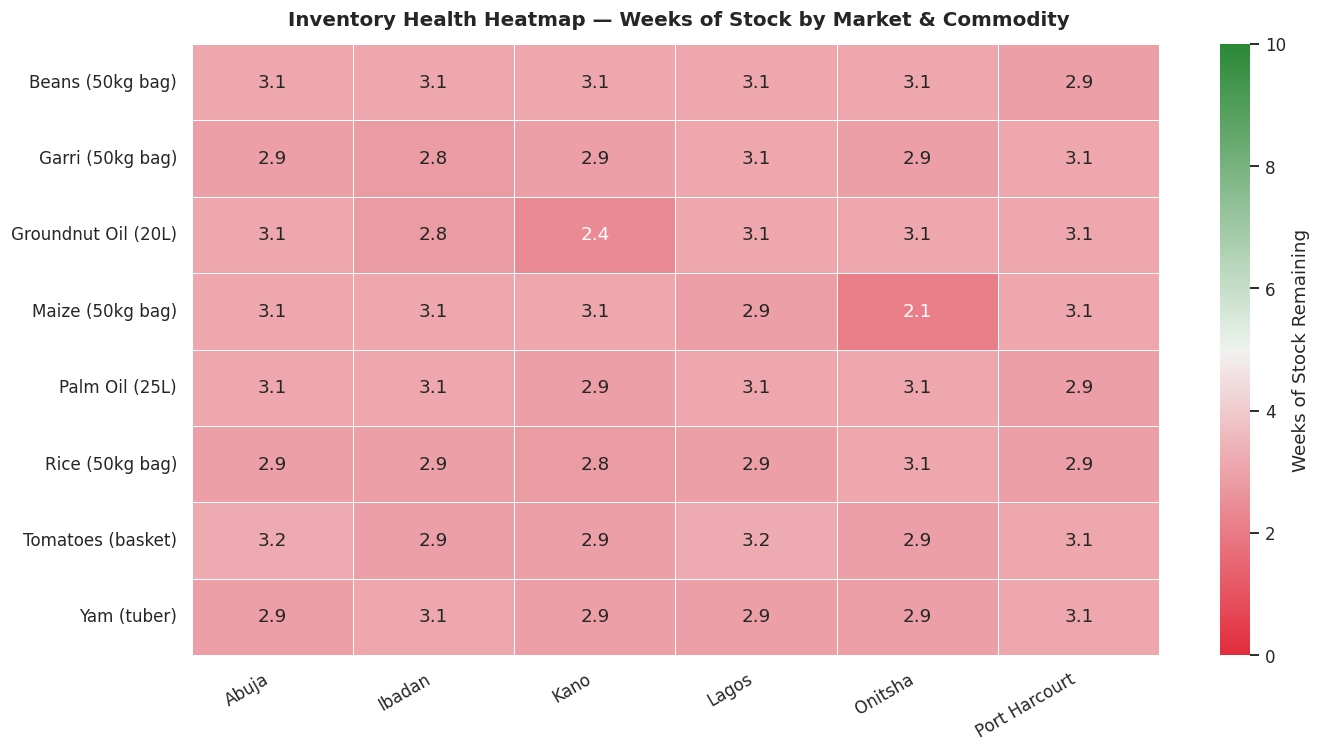

In [20]:
# Inventory Risk Heatmap
pivot = opt_df.pivot(index='commodity', columns='market', values='weeks_of_stock')

fig, ax = plt.subplots(figsize=(13, 7))
cmap = sns.diverging_palette(10, 130, s=85, l=50, as_cmap=True)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, linewidths=0.5,
            linecolor='white', ax=ax, vmin=0, vmax=10,
            cbar_kws={'label': 'Weeks of Stock Remaining'})
ax.set_title(' Inventory Health Heatmap — Weeks of Stock by Market & Commodity',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

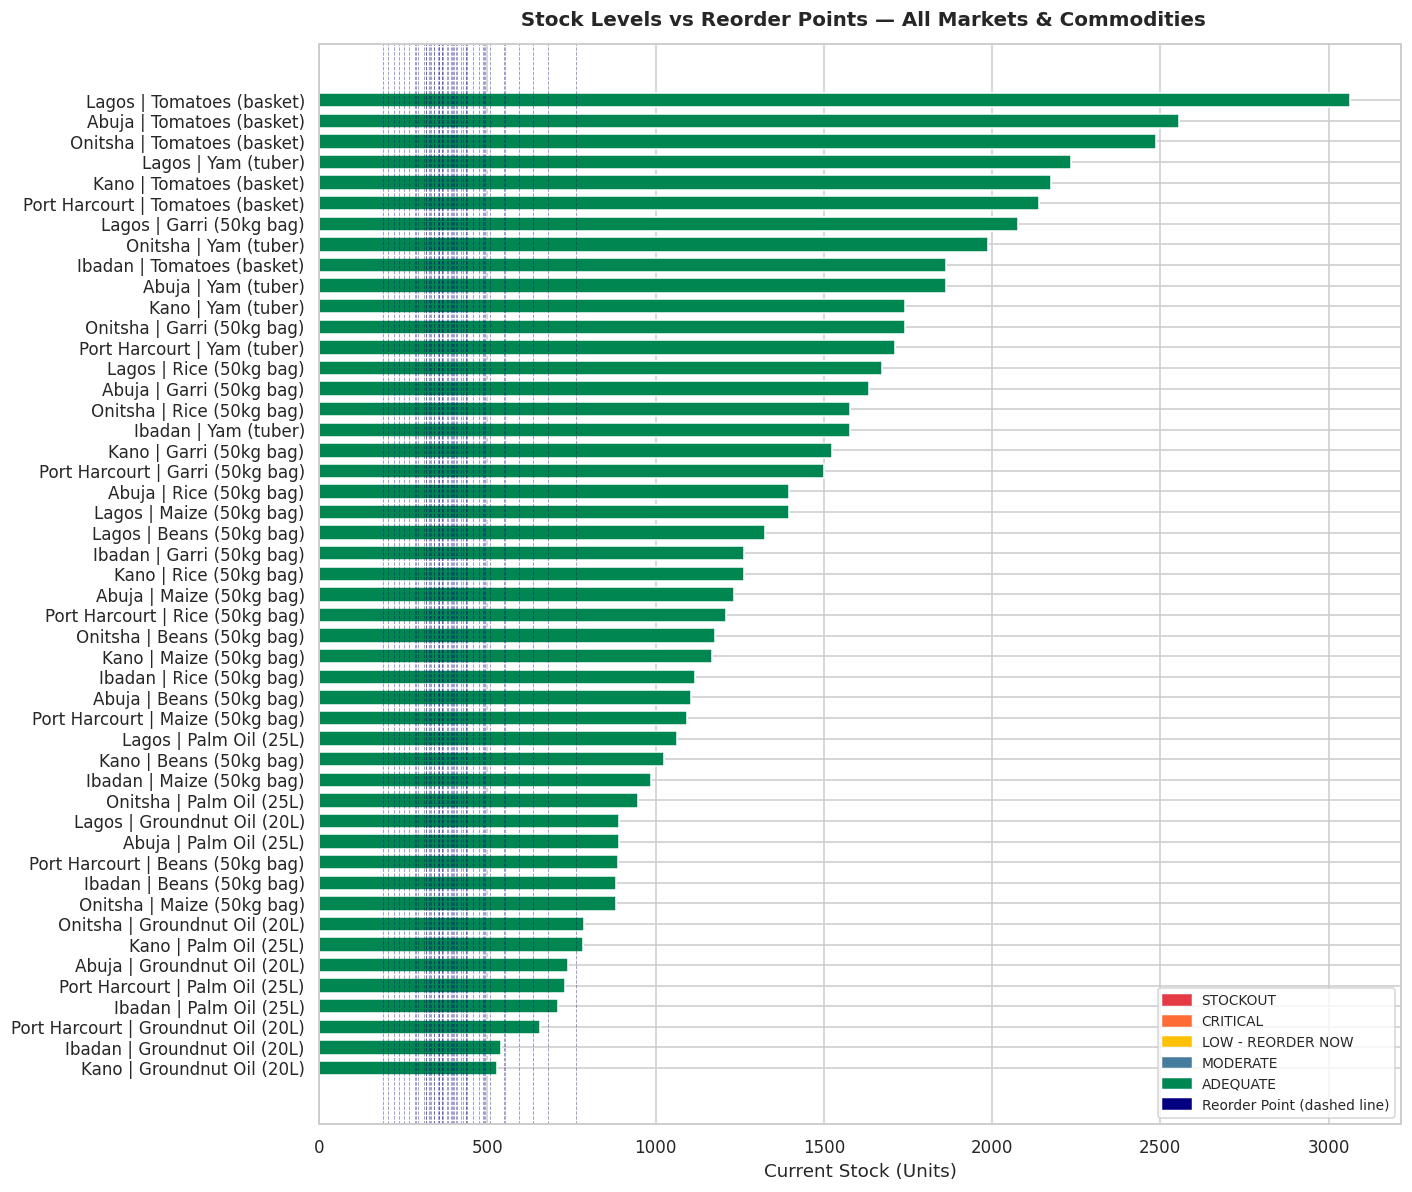

In [21]:
# Reorder Alerts Bar Chart
COLOR_MAP = {
    'STOCKOUT':        '#E63946',
    'CRITICAL':        '#FF6B35',
    'LOW - REORDER NOW': '#FFC107',
    'MODERATE':        '#457B9D',
    'ADEQUATE':        '#008751',
}

# Show all items sorted by stock level
plot_data = opt_df.copy()
plot_data['label'] = plot_data['market'] + ' | ' + plot_data['commodity']
plot_data = plot_data.sort_values('current_stock')
colors = [COLOR_MAP.get(s, '#888') for s in plot_data['risk_status']]

fig, ax = plt.subplots(figsize=(13, 11))
ax.barh(plot_data['label'], plot_data['current_stock'], color=colors, edgecolor='white', height=0.7)
for _, row in plot_data.iterrows():
    ax.axvline(row['reorder_point'], color='navy', linestyle='--', linewidth=0.6, alpha=0.4)

ax.set_title(' Stock Levels vs Reorder Points — All Markets & Commodities',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Current Stock (Units)')
patches = [mpatches.Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
patches.append(mpatches.Patch(color='navy', label='Reorder Point (dashed line)'))
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

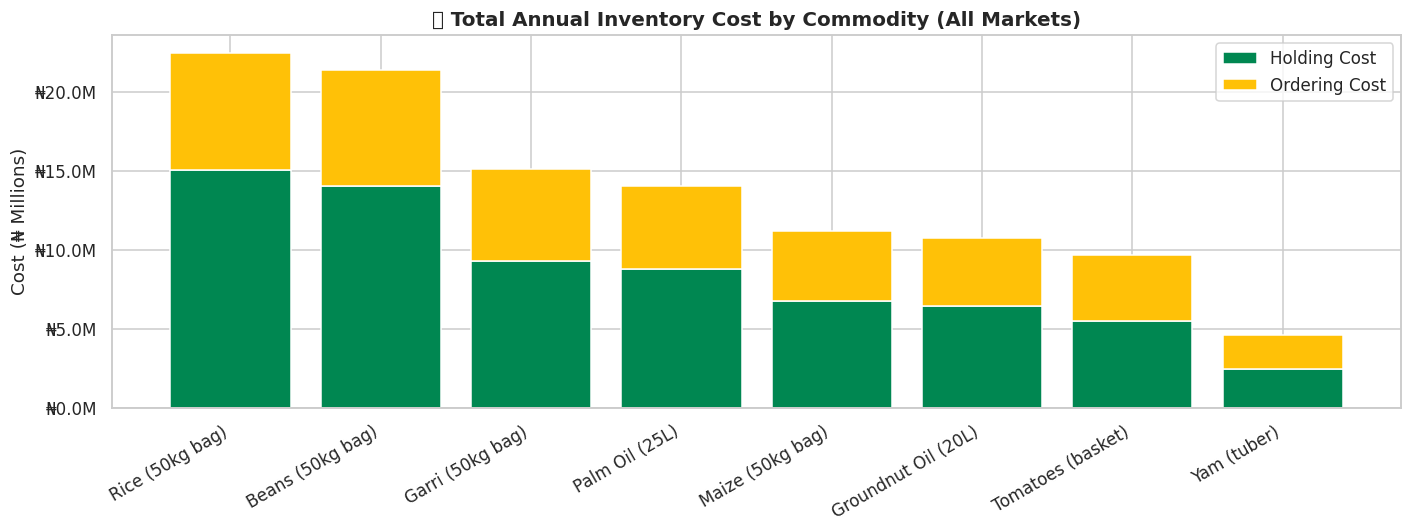

In [22]:
# Annual Cost Breakdown by Commodity
cost_data = opt_df.groupby('commodity')[['annual_holding_cost','annual_ordering_cost']].sum().reset_index()
cost_data = cost_data.sort_values('annual_holding_cost', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cost_data))
ax.bar(x, cost_data['annual_holding_cost'] / 1e6,  label='Holding Cost',  color='#008751', edgecolor='white')
ax.bar(x, cost_data['annual_ordering_cost'] / 1e6, label='Ordering Cost', color='#FFC107', edgecolor='white',
       bottom=cost_data['annual_holding_cost'] / 1e6)

ax.set_xticks(x)
ax.set_xticklabels(cost_data['commodity'], rotation=30, ha='right')
ax.set_title(' Total Annual Inventory Cost by Commodity (All Markets)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cost (₦ Millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'₦{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

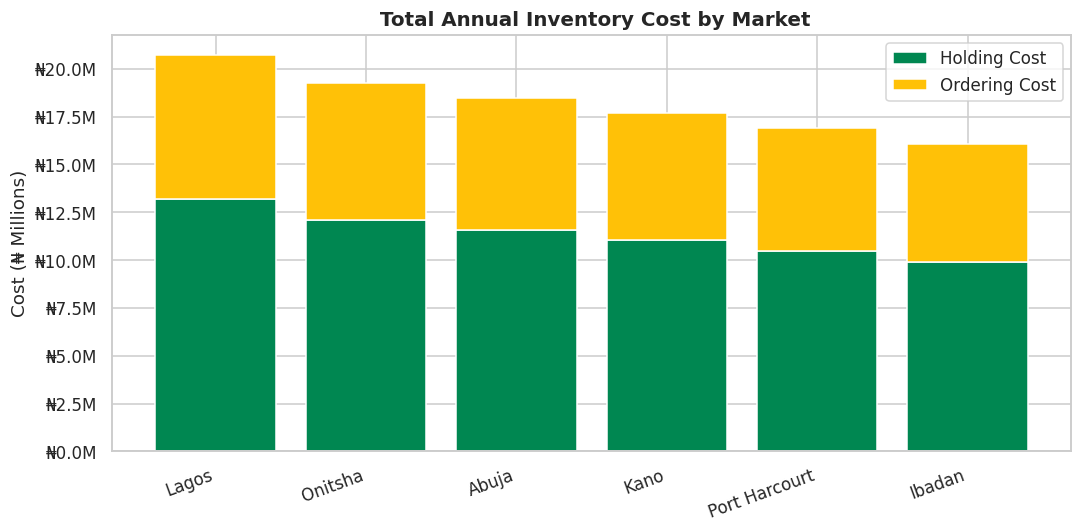

In [23]:
# Cost Breakdown — by Market
cost_market = opt_df.groupby('market')[['annual_holding_cost','annual_ordering_cost']].sum().reset_index()
cost_market = cost_market.sort_values('annual_holding_cost', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cost_market))
ax.bar(x, cost_market['annual_holding_cost'] / 1e6,  label='Holding Cost',  color='#008751', edgecolor='white')
ax.bar(x, cost_market['annual_ordering_cost'] / 1e6, label='Ordering Cost', color='#FFC107', edgecolor='white',
       bottom=cost_market['annual_holding_cost'] / 1e6)

ax.set_xticks(x)
ax.set_xticklabels(cost_market['market'], rotation=20, ha='right')
ax.set_title(' Total Annual Inventory Cost by Market', fontsize=13, fontweight='bold')
ax.set_ylabel('Cost (₦ Millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'₦{v:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

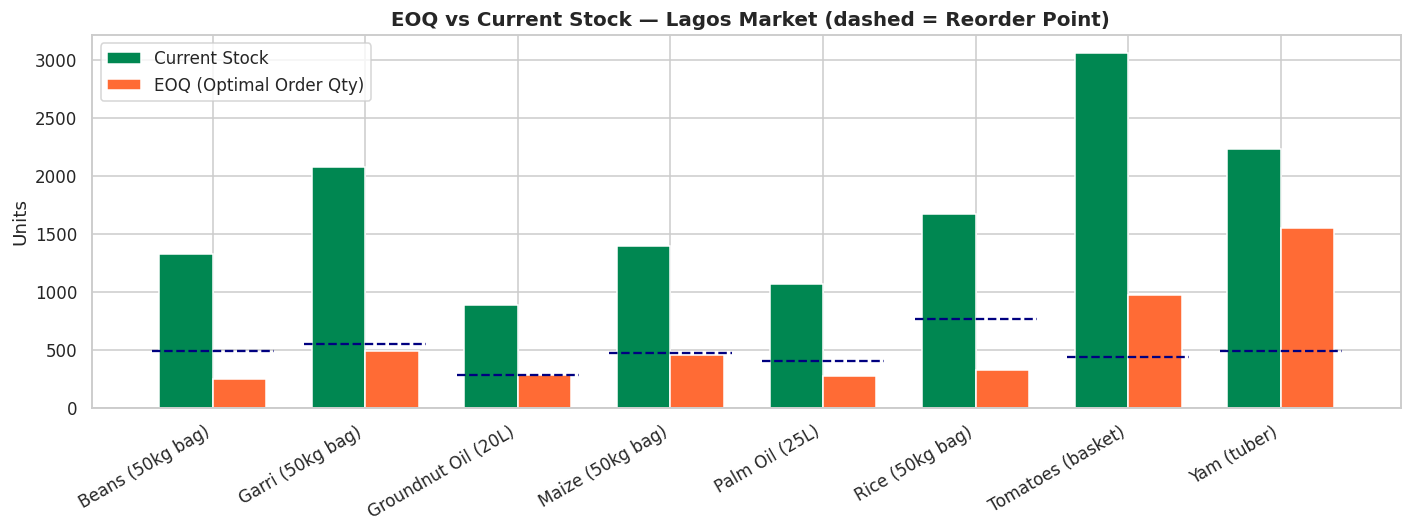

In [24]:
# EOQ vs Current Stock
fig, ax = plt.subplots(figsize=(13, 5))
sample = opt_df[opt_df['market'] == 'Lagos'].sort_values('commodity')
x = np.arange(len(sample))
w = 0.35
ax.bar(x - w/2, sample['current_stock'], w, label='Current Stock', color='#008751', edgecolor='white')
ax.bar(x + w/2, sample['eoq_units'],     w, label='EOQ (Optimal Order Qty)', color='#FF6B35', edgecolor='white')

for i, row in enumerate(sample.itertuples()):
    ax.hlines(row.reorder_point, i - 0.4, i + 0.4, colors='navy', linestyles='--', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(sample['commodity'], rotation=30, ha='right')
ax.set_title(' EOQ vs Current Stock — Lagos Market (dashed = Reorder Point)', fontsize=13, fontweight='bold')
ax.set_ylabel('Units')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

In [25]:
print('  NIGERIA FOOD SUPPLY — SYSTEM SUMMARY')

print(f"""
 Data Period      : {df.date.min().date()} → {df.date.max().date()}
 Markets          : {df.market.nunique()} ({', '.join(df.market.unique())})
 Commodities      : {df.commodity.nunique()}
 Total Records    : {len(df):,}

 FORECASTING
   Model            : Holt-Winters Exponential Smoothing
   Horizon          : 12 weeks ahead
   Pairs forecasted : {len(forecast_results)}
   Avg MAPE         : {fc_summary['MAPE %'].mean():.1f}%

 INVENTORY STATUS
   Total pairs      : {len(opt_df)}
    Adequate      : {len(opt_df[opt_df.risk_status == 'ADEQUATE'])}
    Moderate      : {len(opt_df[opt_df.risk_status == 'MODERATE'])}
    Low/Reorder   : {len(opt_df[opt_df.risk_status == 'LOW - REORDER NOW'])}
    Critical      : {len(opt_df[opt_df.risk_status == 'CRITICAL'])}
    Stockout      : {len(opt_df[opt_df.risk_status == 'STOCKOUT'])}

 COST OPTIMIZATION (Annual, All Markets)
   Holding cost     : ₦{opt_df.annual_holding_cost.sum()/1e6:.1f}M
   Ordering cost    : ₦{opt_df.annual_ordering_cost.sum()/1e6:.1f}M
   Total inv. cost  : ₦{opt_df.total_annual_cost.sum()/1e6:.1f}M
""")

if len(alerts) > 0:
    print(f' ACTIVE ALERTS: {len(alerts)} items require immediate action')
    for _, row in alerts.iterrows():
        print(f"   [{row.risk_status}] {row.commodity} | {row.market} "
              f"→ Order {row.recommended_order_qty} units "
              f"(est. ₦{row.estimated_cost_ngn:,.0f})")
else:
    print(' No critical alerts — all inventory levels are healthy.')

  NIGERIA FOOD SUPPLY — SYSTEM SUMMARY

 Data Period      : 2022-01-02 → 2024-12-29
 Markets          : 6 (Lagos, Kano, Abuja, Port Harcourt, Onitsha, Ibadan)
 Commodities      : 8
 Total Records    : 7,536

 FORECASTING
   Model            : Holt-Winters Exponential Smoothing
   Horizon          : 12 weeks ahead
   Pairs forecasted : 48
   Avg MAPE         : 6.9%

 INVENTORY STATUS
   Total pairs      : 48
    Adequate      : 48
    Moderate      : 0
    Low/Reorder   : 0
    Critical      : 0
    Stockout      : 0

 COST OPTIMIZATION (Annual, All Markets)
   Holding cost     : ₦68.3M
   Ordering cost    : ₦40.9M
   Total inv. cost  : ₦109.2M

 No critical alerts — all inventory levels are healthy.
